In [1]:
# import modules
import numpy as np
import pandas as pd
import scipy.stats as stats
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf
import tensorflow_probability as tfp
tfd = tfp.distributions
tfb = tfp.bijectors

np.set_printoptions(suppress=True)

In [2]:
# Load data
dat=pd.read_csv("Z_score.csv")
dat.head()


,Coef,Observation,beta_1,beta_2,mean1,mean2,sd1,sd2,Z_value,Z_score
0,PN,10000,0.5,-0.8,0.566981,-0.718005,0.153149,0.138900,Z1,-0.437355
1,PN,10000,0.5,-0.8,0.566981,-0.718005,0.153149,0.138900,Z2,-0.590318
2,PN,10000,0.5,-0.8,0.498200,-0.867833,0.148082,0.143339,Z1,0.012154
3,PN,10000,0.5,-0.8,0.498200,-0.867833,0.148082,0.143339,Z2,0.473234
4,PN,10000,0.5,-0.8,0.609360,-0.697771,0.151139,0.137092,Z1,-0.723570


In [3]:
# Sort the values
dat=dat.sort_values(by=["Z_score"])

#Rank from the lowest to highest
dat["Rank"]=np.arange(1,241,1)

# Calculate the percentiles
dat["Percentiles"]=(dat["Rank"]-0.5)/240

# Calculate theoretical quantiles
dat["Theoretical_Z"]=stats.norm.ppf(dat["Percentiles"])

# Calculate Sample quantiles
dat["Sample_Z"]=(dat["Z_score"]-np.mean(dat["Z_score"]))/np.std(dat["Z_score"])

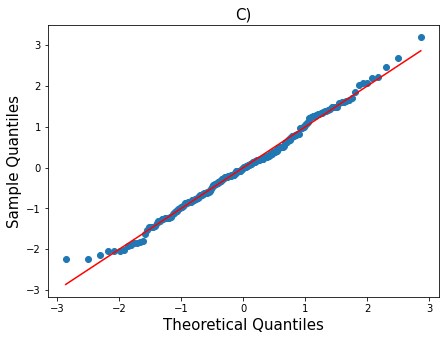

In [4]:
# Plotting QQ-plot
fig=plt.figure(figsize=(7,5))
plt.plot(dat["Theoretical_Z"],dat["Sample_Z"],"o")
plt.plot(dat["Theoretical_Z"],dat["Theoretical_Z"]*1 + 0,color="r")
plt.xlabel("Theoretical Quantiles",fontsize=15)
plt.ylabel("Sample Quantiles",fontsize=15)
plt.title("C)",fontsize=15)
plt.savefig("QQ-plot.png")
plt.show()

2022-10-20 17:10:10.163478: I tensorflow/core/platform/cpu_feature_guard.cc:142] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  SSE4.1 SSE4.2 AVX AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2022-10-20 17:10:10.659488: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1510] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 14805 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0001:00:00.0, compute capability: 7.5


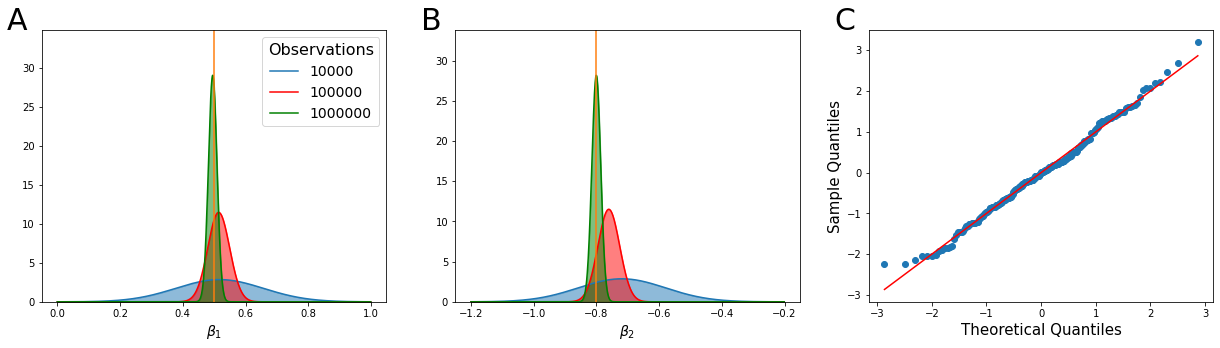

In [5]:
# Plotting probability density of 10000,100000,1000000
x = np.arange(0,1.0,0.001)
K= tfp.distributions.Normal(loc=0.5172282,scale=0.1398239).prob(x)
L = tfp.distributions.Normal(loc=0.5143884,scale=0.0347550).prob(x)
M = tfp.distributions.Normal(loc=0.4953444,scale=0.0137233).prob(x)

fig,ax=plt.subplots(1,3, figsize=(21,5))
ax[0].plot(x,K,c='C0')
ax[0].plot(x,L,c='red')
ax[0].plot(x,M,c='green')
ax[0].fill_between(x,K,color='C0',alpha=0.5)
ax[0].fill_between(x,L,color='red',alpha=0.5)
ax[0].fill_between(x,M,color='green',alpha=0.5)
ax[0].axvline(0.5,c='C1')
ax[0].set_ylim(0,M.numpy().max()*1.2)
ax[0].set_xlabel(r"$\beta_1$",fontsize=14)
ax[0].text(-0.1,1,'A', size=30, transform=ax[0].transAxes)
ax[0].legend(loc="upper right",labels=["10000","100000","1000000"],title="Observations",
             fontsize=14,title_fontsize=16)

x = np.arange(-1.2,-0.2,0.001)
K1= tfp.distributions.Normal(loc=-0.7187936,scale=0.13921396).prob(x)
L1= tfp.distributions.Normal(loc=-0.7604495,scale=0.03463802).prob(x)
M1= tfp.distributions.Normal(loc=-0.8002949,scale=0.01415233).prob(x)

ax[1].plot(x,K1,c='C0')
ax[1].plot(x,L1,c='red')
ax[1].plot(x,M1,c='green')
ax[1].fill_between(x,K1,color='C0',alpha=0.5)
ax[1].fill_between(x,L1,color='red',alpha=0.5)
ax[1].fill_between(x,M1,color='green',alpha=0.5)
ax[1].axvline(-0.8,c='C1')
ax[1].set_ylim(0,M1.numpy().max()*1.2)
ax[1].set_xlabel(r"$\beta_2$", fontsize=14)
ax[1].text(-0.1,1,'B', size=30, transform=ax[1].transAxes)

ax[2].plot(dat["Theoretical_Z"],dat["Sample_Z"],"o")
ax[2].plot(dat["Theoretical_Z"],dat["Theoretical_Z"]*1 + 0,color="r")
ax[2].set_xlabel("Theoretical Quantiles",fontsize=15)
ax[2].set_ylabel("Sample Quantiles",fontsize=15)
ax[2].text(-0.1,1,'C', size=30, transform=ax[2].transAxes)

plt.savefig('Figure2.png')
plt.show()